In [1]:
import numpy as np
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill

import config as cfg 
import bdt_lh_cut_opt_with_n_interp as cutopt
plt.style.use('fcc.mplstyle')

import glob
import sys
import ROOT
import math
from tabulate import tabulate
from yaml import safe_load, YAMLError
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from itertools import combinations
from itertools import product
from scipy.interpolate import interp1d
 
import efficiency_finder

ROOT.EnableImplicitMT()

Welcome to JupyROOT 6.28/10


In [24]:
def set_outputpath(outputpath):
    if not os.path.exists(outputpath):
        os.makedirs(outputpath)
    return outputpath

In [2]:
data = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe_inclmotherinfo.pkl')

In [3]:
#keep desired branches
flavtag_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2","decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbsfull = data.head(20000)
dfbdfull = data.tail(20000).reset_index(drop=True)

In [4]:
#keep desired branches
def filter_df_on_IDs(dfbsfull,dfbdfull,mask_fn, reco_space_branches= reco_space_branches):
    #mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)
    filtered_df_dict={}
    key = ['bs','bd']
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
       
        #create empty dfs to fill
        filtered_df = pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            evt = df.iloc[i]
            mask = mask_fn(evt)
            for var in reco_space_branches:
                filtered_df.loc[i, var] = np.array(evt[var])[mask]
                
        filtered_df_dict[key[s]] = filtered_df
   
    return filtered_df_dict



def filter_df_on_fromPV(dfbsfull, dfbdfull, reco_space_branches= reco_space_branches):
    key = ['bs','bd']
    filtered_df_dict={}
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
        
        #create empty dfs to fill
        filtered_df=pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            from_PV=[]
            for k in range(len(df['Rec_indvtx'][i])):
                if df['Rec_indvtx'][i][k] == -999:
                    from_PV.append(0)
                else:
                    from_PV.append(np.array(df['Rec_vtx_isPV'][i])[df['Rec_indvtx'][i][k]])
            
            frompv_mask = np.array(from_PV)==1
            
            for var in reco_space_branches:
                filtered_df.loc[i, var] = df.loc[i, var][frompv_mask]
    
        filtered_df_dict[key[s]] = filtered_df
    
    return filtered_df_dict

In [5]:
hist_settings={'Bssignal': {}, 'Bdsignal':{} }

hist_settings['Bssignal']['histtype'] = 'step'
hist_settings['Bssignal']['lw'] = 2
hist_settings['Bssignal']['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[3]) #'cornflowerblue'
hist_settings['Bssignal']['hatch'] = '////'

hist_settings['Bdsignal']['histtype'] = 'step'
hist_settings['Bdsignal']['lw'] = 2
hist_settings['Bdsignal']['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[-1]) #-2#'mediumblue'#'royalblue'
hist_settings['Bdsignal']['hatch'] = r'\\\\'

In [31]:
def make_maxpK_plots(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV',savepath=None,plottype=None):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    maxp_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(maxp_bd,bins=40,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],range=(-1,8), density=True, **hist_settings['Bdsignal'])
    plt.hist(maxp_bs,bins=40,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],range=(-1,8), density=True, **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_highest_p_incl-1.pdf'))


     #plot normalised histogram
    plt.hist(maxp_bd,bins=40,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],range=(0,8), density=True, **hist_settings['Bdsignal'])
    plt.hist(maxp_bs,bins=40,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],range=(0,8), density=True, **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_highest_p_incl_non_zero.pdf'))


    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),400):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)

    n_remaining_bs_interp = interp1d(cut_arr, n_remaining_bs, kind = 'quadratic')
    n_remaining_bd_interp = interp1d(cut_arr, n_remaining_bd, kind = 'quadratic')

    cut_arr_interp = np.linspace(0,max(maxp_bs),1000)
    plt.plot(cut_arr,n_remaining_bd,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'], color = hist_settings['Bdsignal']['color'],lw=2,linestyle=(0,(3,1,1,1))) 
    plt.plot(cut_arr,n_remaining_bs,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], color = hist_settings['Bssignal']['color'],lw=2) 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_cut_eff.pdf'))


    ratio = [n_remaining_bs[i] / n_remaining_bd[i] if n_remaining_bd[i] > 0 else 0 for i in range(len(n_remaining_bd))]
    ratio_interp =  interp1d(cut_arr, ratio, kind = 'quadratic')
    
    #plt.plot(cut_arr,ratio)
    plt.plot(cut_arr,ratio) 
    plt.xlim(0,8)
    #plt.ylim(0,30)
    plt.legend()
    plt.xlabel('Cut on $p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Ratio Bs/Bd cut Efficiencies')
    plt.show()

def  make_allpK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    allp_bs =[dfbs['Rec_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['Rec_p'][i]))]
    allp_bd =[dfbd['Rec_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['Rec_p'][i]))]

    #plot hostogram
    plt.hist(allp_bd,bins=40, label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],range=(0,8), density=True, **hist_settings['Bdsignal'])
    plt.hist(allp_bs,bins=40,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],range=(0,8), density=True, **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def  make_nK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV',savepath=None,plottype=None):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    num_K_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bd,bins=6,density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],range=(0,6), **hist_settings['Bdsignal'])
    plt.hist(num_K_bs,bins=6,density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],range=(0,6), **hist_settings['Bssignal'])
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_number.pdf'))


In [7]:
def charged_fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.round(evt['Rec_true_PDG']) == 321) | (np.round(evt['Rec_true_PDG']) == -321)))

def fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)| (np.array(np.round(evt['Rec_true_PDG'])) == 130)))

def fsKL_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & (np.array(np.round(evt['Rec_true_PDG'])) == 130))

def reco_pi0(evt):
    return (((np.round(evt['Rec_true_PDG']) == 111) | (np.round(evt['Rec_true_PDG']) == -111)))


charged_fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,charged_fsK_mask)
fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsK_mask)
fsKL_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKL_mask)
pi0dict = filter_df_on_IDs(dfbsfull,dfbdfull,reco_pi0)

charged_fsK_dict_fromPV = filter_df_on_IDs(charged_fsK_dict['bs'],charged_fsK_dict['bd'],charged_fsK_mask)
fsK_dict_fromPV = filter_df_on_IDs(fsK_dict['bs'],fsK_dict['bd'],fsK_mask)
fsKL_dict_fromPV = filter_df_on_IDs(fsKL_dict['bs'],fsKL_dict['bd'],fsKL_mask)

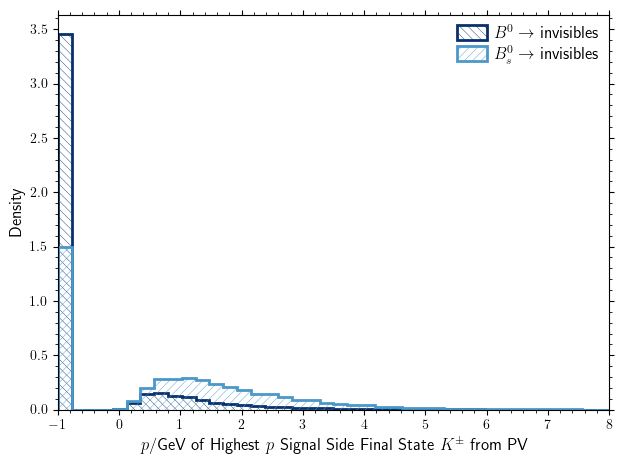

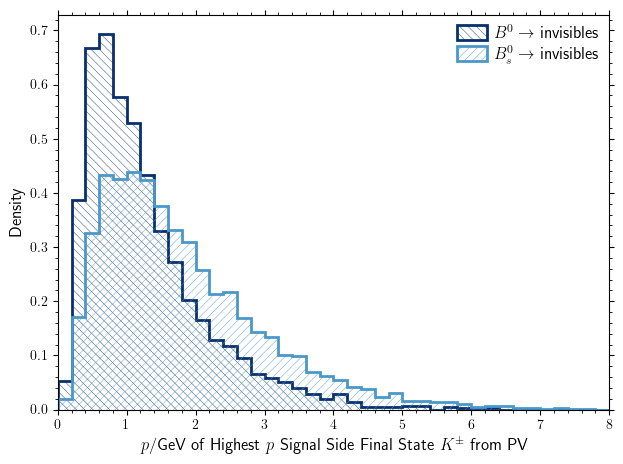

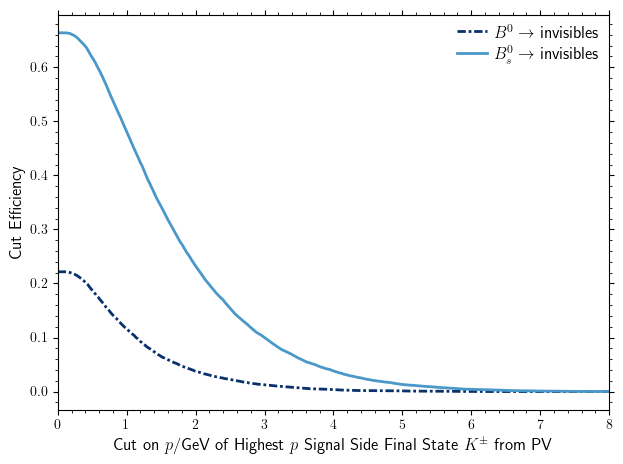

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


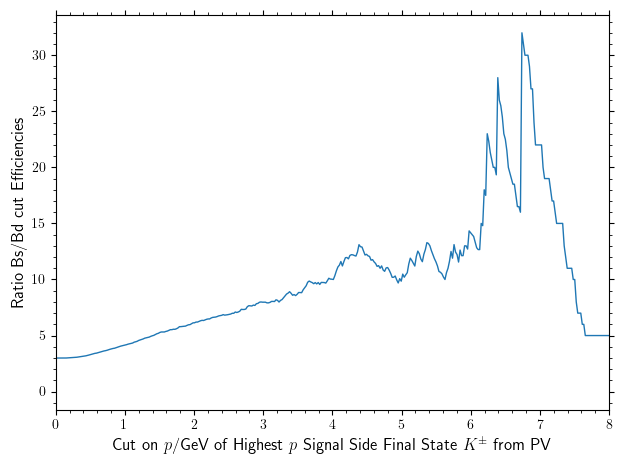

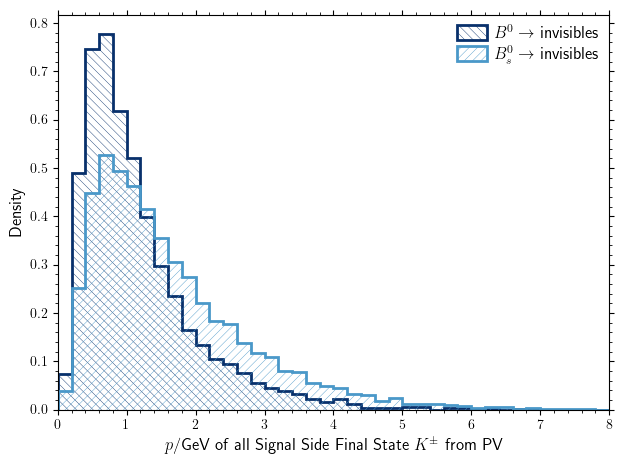

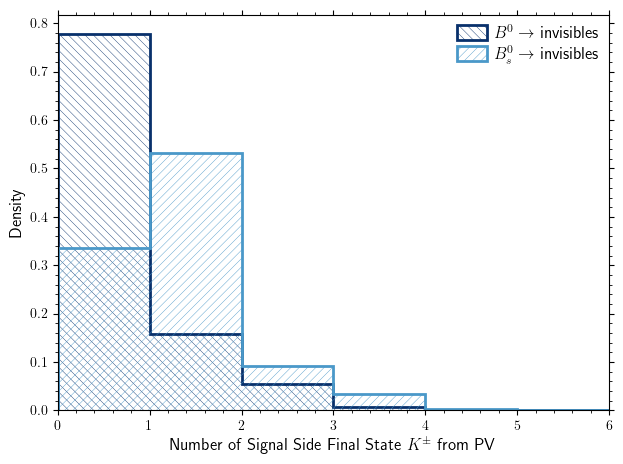

<Figure size 640x480 with 0 Axes>

In [32]:
#for charged fsk
make_maxpK_plots(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV', savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging/',plottype='chargedK')
make_allpK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')
make_nK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV', savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging/',plottype='chargedK')

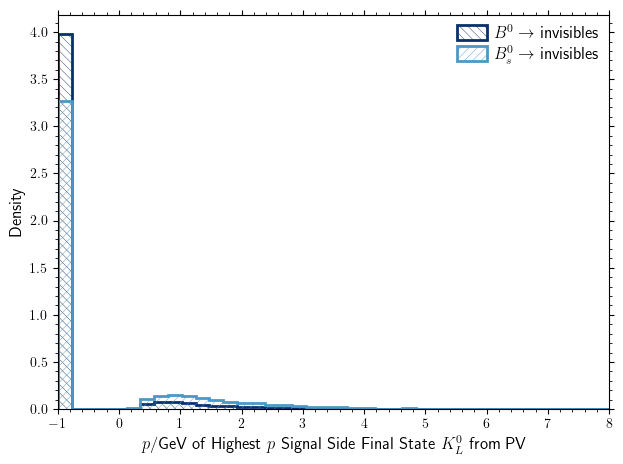

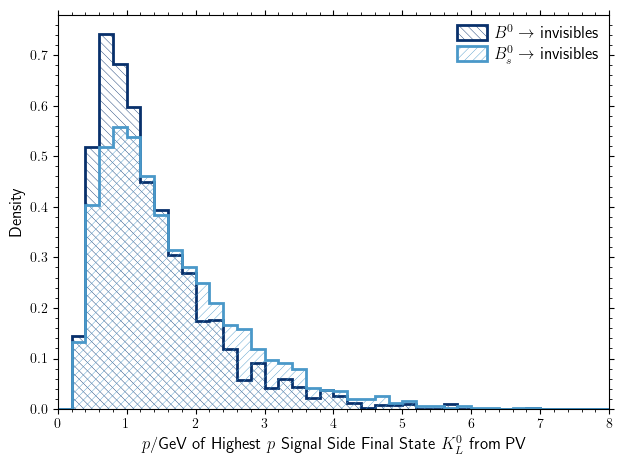

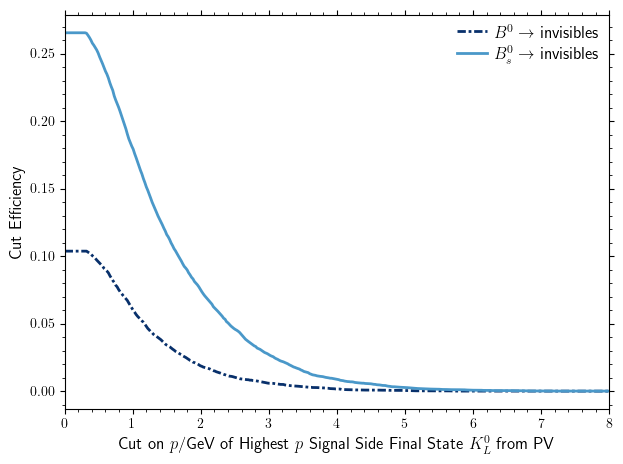

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


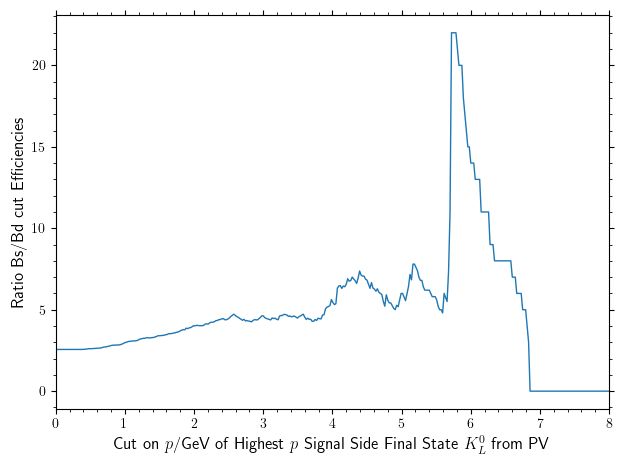

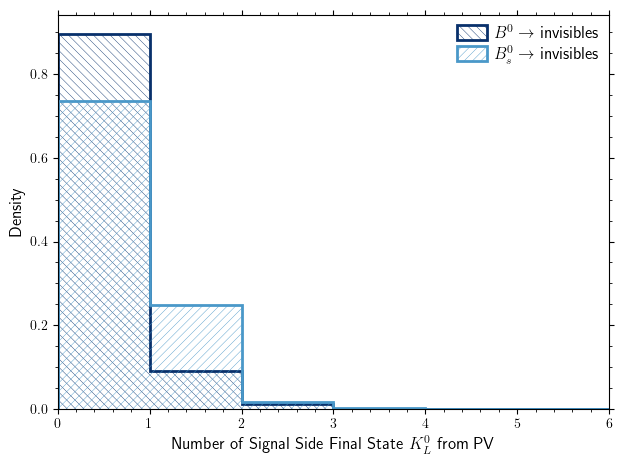

In [9]:
#for Kl
make_maxpK_plots(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV', savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging',plottype='KL')
make_nK_plot(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV', savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging',plottype='KL')

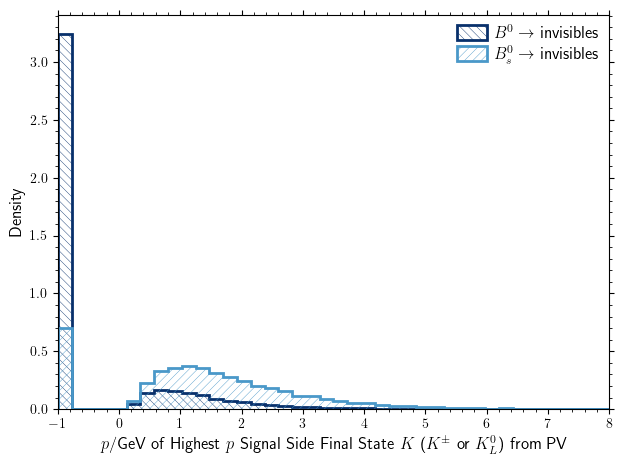

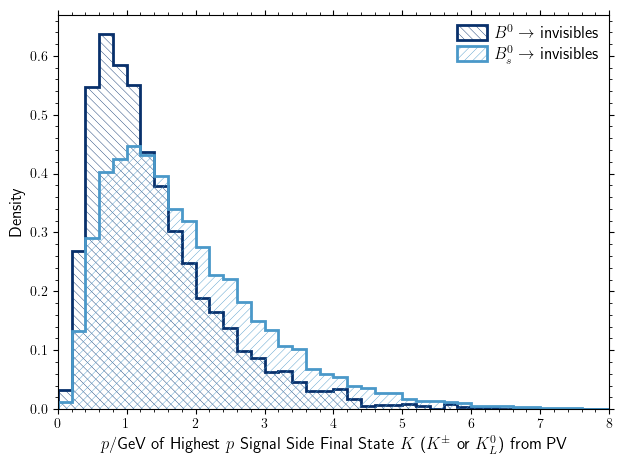

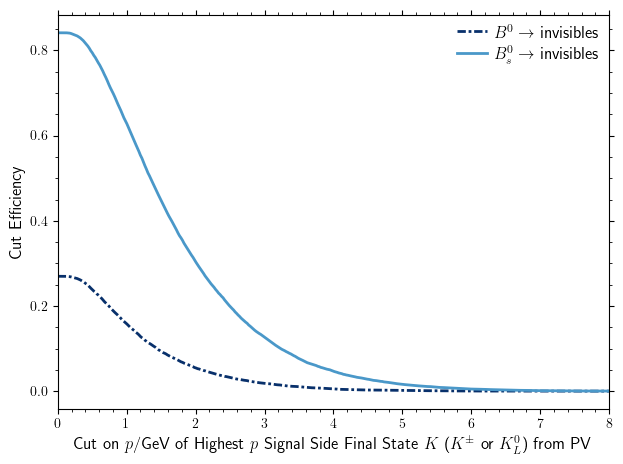

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


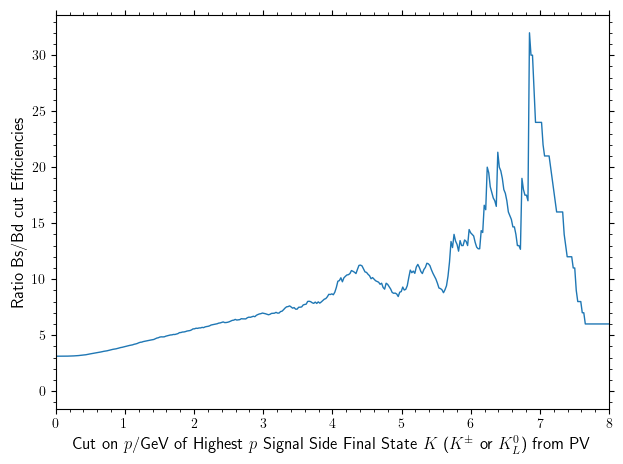

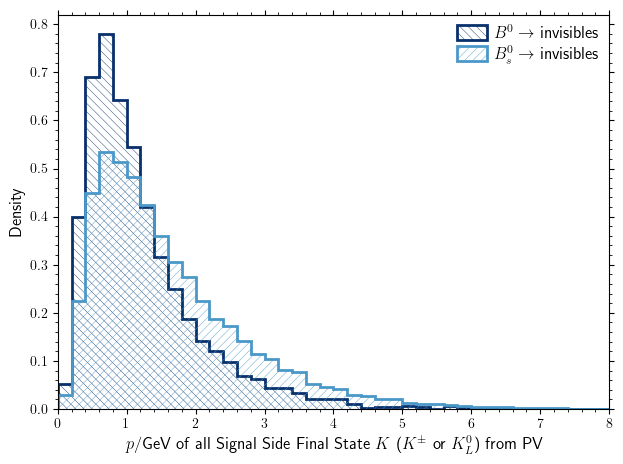

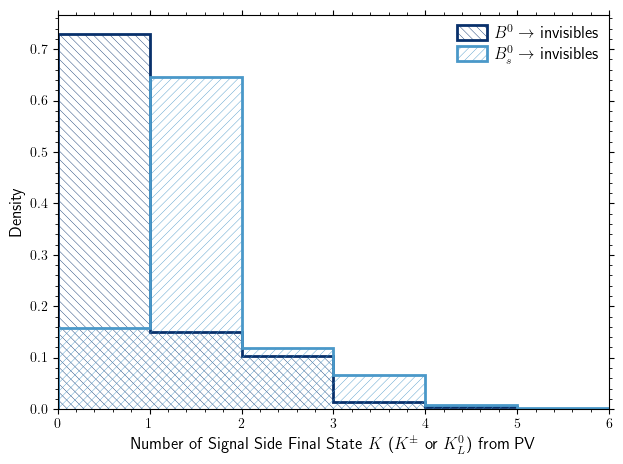

In [10]:
# for all fsK
make_maxpK_plots(fsK_dict_fromPV)
make_allpK_plot(fsK_dict_fromPV)
make_nK_plot(fsK_dict_fromPV)

## $K_S^0$ - deal with separately as have to reconstruct


In [11]:
def fsKS_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_M1'])) == 310)|(np.array(np.round(evt['Rec_true_M2'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM2'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM2'])) == 310)))

fsKS_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKS_mask)

In [12]:
#remove empty rows for ease of figuring out reco

filtered_KS={}
for key in fsKS_dict.keys():
    indextoremover = fsKS_dict[key][[len(fsKS_dict[key]['Rec_p'][i]) == 0 for i in range(len(fsKS_dict[key]['Rec_p']))]].index
    filtered_KS[key] = fsKS_dict[key].drop(indextoremover, inplace=False)

In [13]:
## Create events containing fully reconstructed events only - for this must have even number of pi- and pi+ and have photons in multiples of 4
KSreconstructed = {}
KSpartreco = {}
for key in filtered_KS.keys():

    part_reco=[]
    #loop through events
    for i in filtered_KS[key].index:
        evt = filtered_KS[key].loc[i]

        if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==211]) != len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==-211])):
            part_reco.append(i)
        elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])%4!=0):
            part_reco.append(i)

    KSreconstructed[key]= filtered_KS[key].drop(part_reco, inplace=False)
    KSpartreco[key]= filtered_KS[key].loc[part_reco]

In [14]:
KSpartreco['bs']

for key in KSpartreco.keys():

    multiple=[]
    #loop through events
    for i in KSpartreco[key].index:
        evt = KSpartreco[key].loc[i]

        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])>2):
            multiple.append(i)
        elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])>4):
            multiple.append(i)


KSpartreco[key].loc[multiple]

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
35,"[0.12159787118434906, 0.08147004246711731, 2.0...","[0.12159787118434906, 0.08147004246711731, 2.0...","[0.11935321986675262, 0.08057697117328644, 1.8...","[0.004044904373586178, -0.004702216014266014, ...","[-0.022901730611920357, 0.011072895489633083, ...","[0.11942174285650253, 0.08071406185626984, 1.9...","[22.0, 22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1, 1]","[-999, -999, -999, -999, -999]","[111, 111, 111, 111, 111]","[0, 0, 0, 0, 0]","[310, 310, 310, 310, 310]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
192,"[0.24819885194301605, 0.3701367676258087, 0.17...","[0.24819883704185486, 0.3701367676258087, 0.17...","[0.21948151290416718, 0.3014798164367676, 0.05...","[-0.01462933886796236, -0.13182397186756134, 0...","[-0.1149630919098854, -0.16950981318950653, -0...","[0.2199685275554657, 0.3290404677391052, 0.163...","[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1, 1, 1, 1]","[-999, -999, -999, -999, -999, -999, -999]","[111, 111, 111, 111, 111, 111, 111]","[0, 0, 0, 0, 0, 0, 0]","[310, 310, 310, 310, 310, 310, 310]","[0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0]"
1249,"[0.07964449375867844, 0.261837899684906, 0.250...","[0.07964450120925903, 0.261837899684906, 0.250...","[-0.06174544245004654, 0.1325075775384903, 0.0...","[-0.03992181271314621, -0.18194594979286194, -...","[0.03061038628220558, 0.13377779722213745, 0.1...","[0.07352720946073532, 0.22508351504802704, 0.2...","[22.0, 22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1, 1]","[-999, -999, -999, -999, -999]","[111, 111, 111, 111, 111]","[0, 0, 0, 0, 0]","[310, 310, 310, 310, 310]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
1294,"[0.3431999981403351, 0.09703981131315231, 0.16...","[0.3431999981403351, 0.09703981131315231, 0.16...","[0.055817071348428726, -0.04967418313026428, -...","[0.17158585786819458, 0.021426264196634293, 0....","[-0.29194003343582153, -0.08056125044822693, -...","[0.18043628334999084, 0.05409814417362213, 0.1...","[22.0, 22.0, 22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1, 1, 1]","[-999, -999, -999, -999, -999, -999]","[111, 111, 111, 111, 111, 111]","[0, 0, 0, 0, 0, 0]","[310, 310, 310, 310, 310, 310]","[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0]"
2156,"[1.225813627243042, 0.532734215259552, 0.18188...","[1.2178419828414917, 0.5141263604164124, 0.116...","[0.6521512866020203, 0.18270348012447357, 0.11...","[-0.598203182220459, -0.04964235797524452, 0.0...","[0.836654543876648, 0.477996826171875, -0.0339...","[0.8849567174911499, 0.18932756781578064, 0.11...","[211.0, -211.0, -211.0]","[1, 1, 1]","[1, 1, 2]","[310, 310, 310]","[0, 0, 0]","[311, 311, -311]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18517,"[0.22875875234603882, 0.0234905406832695, 0.23...","[0.22875875234603882, 0.02349054254591465, 0.2...","[0.2105061411857605, 0.022638801485300064, -0....","[0.06564760208129883, -0.006151605863124132, 0...","[-0.060894351452589035, 0.0012033169623464346,...","[0.2205049693584442, 0.023459700867533684, 0.1...","[22.0, 22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1, 1]","[-999, -999, -999, -999, -999]","[111, 111, 111, 111, 111]","[0, 0, 0, 0, 0]","[310, 310, 310, 310, 310]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
18532,"[1.0163893699645996, 0.419023334980011, 0.3322...","[1.006760835647583, 0.39509573578834534, 0.332...","[-0.1069185882806778, 0.18666845560073853, 0.1...","[-1.0008717775344849, -0.33994656801223755, -0...","[0.019786939024925232, 0.07544445246458054, -0...","[1.0065664052963257, 0.38782569766044617, 0.31...","[211.0, -211.0, 22.0, 22.0, 22.0, 22.0, 22.0, ...","[1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, -999, -999, -999, -999, -999, -999]","[310, 310, 111, 111, 111, 111, 111, 111]","[0, 0, 0, 0, 0, 0, 0, 0]","[-311, -311, 310, 310, 310, 310, 310, 310]","[0

In [15]:
print(len(filtered_KS['bs']))
print(len(KSreconstructed['bs']))
print(len(KSpartreco['bs']))

4077
2450
1627


In [16]:
print(len(filtered_KS['bd']))
print(len(KSreconstructed['bd']))
print(len(KSpartreco['bd']))

1947
838
1109


In [17]:
def run_pairing_reconstruction(E,px,py,pz, parent_invariant_mass):

    n = len(E)
    indices = list(range(len(E)))

    # Step 1: Generate all index pairs (i < j)
    all_pairs = list(combinations(indices, 2))

    # Step 2: Filter for combinations of pairs that:
    # - cover all indices
    # - do not share any index (i.e., disjoint pairs)
    def is_disjoint(pairing):
        used = set()
        for i, j in pairing:
            if i in used or j in used:
                return False
            used.update([i, j])
        return True

    # Step 3: Generate all combinations of n//2 pairs
    valid_pairings = []
    for combo in combinations(all_pairs, n // 2):
        if is_disjoint(combo):
            valid_pairings.append(combo)


    # Step 4: Compute the sum of each valid pairing set
    results = []
    for pairing in valid_pairings:

        total_E = np.array([E[i] + E[j] for i, j in pairing])
        total_px =  np.array([px[i] + px[j] for i, j in pairing])
        total_py =  np.array([py[i] + py[j] for i, j in pairing])
        total_pz =  np.array([pz[i] + pz[j] for i, j in pairing])

        abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - parent_invariant_mass))
        results.append((pairing, abs_total_inv_mass_diff_sum))

    min_pairing, min_total = min(results, key=lambda x: x[1])

    print(min_total)

    return min_pairing


def run_charged_pairing_reconstruction(E_p,px_p,py_p,pz_p, E_m,px_m,py_m,pz_m, parent_invariant_mass):

    n_p = len(E_p)
    n_m = len(E_m)

    indicesp = list(range(len(E_p)))
    indicesm = list(range(len(E_m)))

    # Step 1: Generate all pairings (inexp,indexm)
    all_pairs = list(product(indicesp, indicesm))


    # Step 2: Filter for combinations of pairs that:
    # - cover all indices
    # - do not share any index (i.e., disjoint pairs)
    def is_disjoint(pairing):
        used = set()
        for i, j in pairing:
            if i in used or j+ len(E_p)  in used:
                return False
            used.update([i, j+ len(E_p)])
        return True

    # Step 3: Generate all combinations of n//2 pairs
    valid_pairings = []
    for combo in combinations(all_pairs, (min(n_p,n_m))): #(n_p+n_m) // 2
        if is_disjoint(combo):
            valid_pairings.append(combo)



    # Step 4: Compute the sum of each valid pairing set
    results = []
    for pairing in valid_pairings:
        total_E = np.array([E_p[i] + E_m[j] for i, j in pairing])
        total_px =  np.array([px_p[i] + px_m[j] for i, j in pairing])
        total_py =  np.array([py_p[i] + py_m[j] for i, j in pairing])
        total_pz =  np.array([pz_p[i] + pz_m[j] for i, j in pairing])

        abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - parent_invariant_mass))
        results.append((pairing, abs_total_inv_mass_diff_sum))

    min_pairing, min_total = min(results, key=lambda x: x[1])

    print(min_total)

    return min_pairing







In [18]:
#Run fake intermediate reconstruction of part reco events

KS_PDG_m = cfg.mass_KS
pi0_PDG_m = cfg.mass_pi0


for key in KSpartreco.keys():

    #create KS_p colum
    KSpartreco[key]['KS_p'] = pd.Series(
        [np.array([]) for _ in range(len(KSpartreco[key]))],
        index=KSpartreco[key].index,dtype=object)
    

    for i in KSpartreco[key].index:
        evt = KSpartreco[key].loc[i]
        KS_p=[]


        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))==2:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)
            
            
        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))>2:
        
            #print(evt['Rec_true_PDG'])
            E_p = evt['Rec_e'][(evt['Rec_true_PDG']==211)]
            px_p = evt['Rec_px'][(evt['Rec_true_PDG']==211)]
            py_p = evt['Rec_py'][(evt['Rec_true_PDG']==211)]
            pz_p = evt['Rec_pz'][(evt['Rec_true_PDG']==211)]

            E_m = evt['Rec_e'][(evt['Rec_true_PDG']==-211)]
            px_m = evt['Rec_px'][(evt['Rec_true_PDG']==-211)]
            py_m = evt['Rec_py'][(evt['Rec_true_PDG']==-211)]
            pz_m = evt['Rec_pz'][(evt['Rec_true_PDG']==-211)]
            
            optimum_pairing = run_charged_pairing_reconstruction(E_p,px_p,py_p,pz_p, E_m,px_m,py_m,pz_m, KS_PDG_m)

            KS_px =  np.array([px_p[i] + px_m[j] for i, j in optimum_pairing])
            KS_py =  np.array([py_p[i] + py_m[j] for i, j in optimum_pairing])
            KS_pz =  np.array([pz_p[i] + pz_m[j] for i, j in optimum_pairing])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)
            KS_p.extend(p)

                
        #else:
            #print(f"Number of charged pions= {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])}")
     

        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))==4:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)

        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))>4:
            E = evt['Rec_e'][(evt['Rec_true_PDG']==22)]
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            #reconstruct photon pairs into neutral pions
            optimum_pairing_pi0 = run_pairing_reconstruction(E,px,py,pz, pi0_PDG_m)

            pi0_E =  np.array([E[i] + E[j] for i, j in optimum_pairing_pi0])
            pi0_px =  np.array([px[i] + px[j] for i, j in optimum_pairing_pi0])
            pi0_py =  np.array([py[i] + py[j] for i, j in optimum_pairing_pi0])
            pi0_pz =  np.array([pz[i] + pz[j] for i, j in optimum_pairing_pi0])
            #reconstruct pi0 pairs into KS
            optimum_pairing_KS = run_pairing_reconstruction(pi0_E,pi0_px,pi0_py,pi0_pz, KS_PDG_m)

            KS_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in optimum_pairing_KS])
            KS_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in optimum_pairing_KS])
            KS_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in optimum_pairing_KS])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)

            KS_p.extend(p)

        #else:
            #print(f"Number of photons = {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)])}")

        # add back into initial df
        KSpartreco[key].at[i, 'KS_p']= np.array(KS_p)




0.012363164320193062
0.010031753476918814
0.02271126883772967
0.09989815873805946
0.007067742773380237
0.006825507220079685
0.00728711381932759
0.11822791838666469
0.010587409733466946
0.00727193661239367
0.04653199928384977
0.02954010222730019
0.013844765953551275
0.02521152470918181
0.0017775904185682867
0.024493499292194992
0.036022455430046174
0.09736391131132659
0.014616399627462084
0.027556499226025516
0.006804201306653435
0.01123927057086646
0.01275461224376806
0.0005555490368299165
0.012296290829063944
0.024420276526940343
0.019099683416440694
0.002635119316656165
0.024677600569287875
0.015792371243583625
0.30531488196557444
0.03229727139588512
0.013448002817841698
0.00821071045765065
0.00013670677502336526
0.0004718011955537893
0.005739924725344847
0.0009657113796014971
0.007049011949198769
0.002590910615842379
0.02544251876708703
0.0408700136013771
0.02595224669110413
0.036792352190627764
0.00098244796116026
1.411765058378922e-05
0.033369216598375176
0.059469903144477476


0.0419096573776756
0.056238166038822646
0.00035472481895154617
0.011994859151683634
0.0008987175635568612
0.02440290246875268
0.0060344021383282875
0.00020270497683433364
4.85923376196129e-05
0.014794284303022195
0.03510254279655123
0.00025560507500821394
0.012400026512523282
0.03108118649465863
0.00021777333501726837
0.0003294379468777864
0.016146026603074293
0.005034605521047564
0.06288078328161238
0.00011639460753271047
0.02173102425573288
0.02678737246038887
0.00015857545802161477
0.0001908674898515872
0.029185043323807086
0.004756629346360675
0.018927481514877414
0.026486087829568516
0.01973291755847234
0.01741080892189839
0.0008036542269067581
0.0055518841061467095
0.014773388383536312
0.050557247625316576
0.016240948988989867
0.00018805836555252364
0.018403621291397443
0.01375713408521062
0.012648253200847226
0.011600916612682033
0.02149876772563454
0.018926119642687034
0.0005705433042211272
0.00014360767661725227
0.132513277862715
0.07849278630196166
0.010911925460353494
0.0060

In [19]:
# Run fake intermediate reconstruction

KS_PDG_m = cfg.mass_KS
pi0_PDG_m = cfg.mass_pi0


for key in KSreconstructed.keys():

    #create KS_p colum
    KSreconstructed[key]['KS_p'] = pd.Series(
        [np.array([]) for _ in range(len(KSreconstructed[key]))],
        index=KSreconstructed[key].index,dtype=object)

    for i in KSreconstructed[key].index:
        evt = KSreconstructed[key].loc[i]
        KS_p=[]


        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))==2:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)
            
            
        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))>2:

            E_p = evt['Rec_e'][(evt['Rec_true_PDG']==211)]
            px_p = evt['Rec_px'][(evt['Rec_true_PDG']==211)]
            py_p = evt['Rec_py'][(evt['Rec_true_PDG']==211)]
            pz_p = evt['Rec_pz'][(evt['Rec_true_PDG']==211)]

            E_m = evt['Rec_e'][(evt['Rec_true_PDG']==-211)]
            px_m = evt['Rec_px'][(evt['Rec_true_PDG']==-211)]
            py_m = evt['Rec_py'][(evt['Rec_true_PDG']==-211)]
            pz_m = evt['Rec_pz'][(evt['Rec_true_PDG']==-211)]


            #optimum_pairing = run_pairing_reconstruction(E,px,py,pz, KS_PDG_m)
            optimum_pairing = run_charged_pairing_reconstruction(E_p,px_p,py_p,pz_p, E_m,px_m,py_m,pz_m, KS_PDG_m)

            KS_px =  np.array([px_p[i] + px_m[j] for i, j in optimum_pairing])
            KS_py =  np.array([py_p[i] + py_m[j] for i, j in optimum_pairing])
            KS_pz =  np.array([pz_p[i] + pz_m[j] for i, j in optimum_pairing])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)
            KS_p.extend(p)


            ''' #Old doesn't force correct charge pairing
            E = evt['Rec_e'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]

            optimum_pairing = run_pairing_reconstruction(E,px,py,pz, KS_PDG_m)

            KS_px =  np.array([px[i] + px[j] for i, j in optimum_pairing])
            KS_py =  np.array([py[i] + py[j] for i, j in optimum_pairing])
            KS_pz =  np.array([pz[i] + pz[j] for i, j in optimum_pairing])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)
            KS_p.extend(p)
            '''


        #else:
            #print(f"Number of charged pions= {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])}")
         

        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))==4:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)

        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))>4:
            E = evt['Rec_e'][(evt['Rec_true_PDG']==22)]
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            #reconstruct photon pairs into neutral pions
            optimum_pairing_pi0 = run_pairing_reconstruction(E,px,py,pz, pi0_PDG_m)

            pi0_E =  np.array([E[i] + E[j] for i, j in optimum_pairing_pi0])
            pi0_px =  np.array([px[i] + px[j] for i, j in optimum_pairing_pi0])
            pi0_py =  np.array([py[i] + py[j] for i, j in optimum_pairing_pi0])
            pi0_pz =  np.array([pz[i] + pz[j] for i, j in optimum_pairing_pi0])
            #reconstruct pi0 pairs into KS
            optimum_pairing_KS = run_pairing_reconstruction(pi0_E,pi0_px,pi0_py,pi0_pz, KS_PDG_m)

            KS_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in optimum_pairing_KS])
            KS_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in optimum_pairing_KS])
            KS_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in optimum_pairing_KS])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)

            KS_p.extend(p)
        
        #else:
            #print(f"Number of photons = {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)])}")

        # add back into initial df
        KSreconstructed[key].at[i, 'KS_p']= np.array(KS_p)




0.0017231354818869615
0.00014410248805624137
0.0005063009418416753
0.0016319581177952625
0.000238130097479472
0.0006073621091084447
0.0004632498575464772
0.0004644726143143707
0.0001442438933692558
0.018944031067576195
0.0568483674681356
0.000504349660417347
0.1094318770367456
0.3411702548048531
0.00016720842796119628
0.06560756210762743
0.3003130832741299
0.056251964075492863
0.08671877872397094
0.0023819623459640504
0.0005303993503893989
0.0005644486510342772
0.013969719228369648
0.02261408281121191
0.05554161065235011
0.020671116481720264
0.026658380875470566
0.04840885192933558
0.0004522366771584352
0.00040796929215064504
0.031586366744496844
0.042368216732701136
0.03510564609721761
0.04577878534384555
0.00042867022675652233
0.023215561620830077
0.0773688457957265
0.0265744174575627
0.041752090543862974
0.0005670876615791465
0.0006981926945812678
0.02493552966001439
0.0762283960979857
0.0013510076022492656
0.0008457888784476619
0.002018814159824467
3.456244403787778e-05
0.000341227

In [20]:
KSreconstructed['bs']

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2,KS_p
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[1.2219456331172156]
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[2.3215035551723253]
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[0.5742841369536372]
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[0.7689610478064202]
49,"[0.15689153969287872, 1.0405622720718384, 1.57...","[0.15689153969287872, 1.0405622720718384, 1.57...","[0.053905148059129715, 0.480439692735672, 0.86...","[0.07558070868253708, 0.5474395751953125, 0.75...","[-0.12647823989391327, -0.7431403398513794, -1...","[0.09283430874347687, 0.7283627986907959, 1.14...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[3.5433935391444296]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19958,"[1.6780316829681396, 2.3072056770324707]","[1.6722172498703003, 2.3029801845550537]","[0.6907011866569519, 0.9524847269058228]","[-1.161697268486023, -1.249131202697754]","[0.9847344160079956, 1.6840908527374268]","[1.3515208959579468, 1.570845603942871]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]",[3.95408424026291]
19966,"[0.2967833876609802, 0.15022020041942596, 0.46...","[0.2967833876609802, 0.15022020041942596, 0.46...","[0.17226195335388184, -0.08041469752788544, -0...","[-0.24167011678218842, -0.09116344153881073, -...","[-0.0013223467394709587, 0.08825424313545227, ...","[0.29678043723106384, 0.12156190723180771, 0.3...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[0.8856424301455506]
19968,"[0.041203808039426804, 0.29469189047813416, 0....","[0.041203808039426804, 0.29469189047813416, 0....","[0.007227352354675531, 0.19828781485557556, 0....","[0.013136415742337704, -0.1756388545036316, -0...","[-0.03837908059358597, -0.12913654744625092, -...","[0.014993333257734776, 0.2648906707763672, 0.4...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[0.9330604468287959]
19980,"[1.0480924844741821, 0.5089632272720337, 0.330...","[1.0480924844741821, 0.5089632272720337, 0.330...","[0.26526781916618347, 0.05900021269917488, 0.

In [21]:
# add bakc into original df so that have- ones for non-KS

for key in fsKS_dict.keys():
    fsKS_dict[key]['KS_p'] = pd.Series(
        [np.array([]) for _ in range(len(fsKS_dict[key]))],
        index=fsKS_dict[key].index,dtype=object)

    for i in KSreconstructed[key].index:
        fsKS_dict[key].at[i, 'KS_p'] = KSreconstructed[key]['KS_p'][i]

    for i in KSpartreco[key].index:
        fsKS_dict[key].at[i, 'KS_p'] = KSpartreco[key]['KS_p'][i]




In [35]:
def make_maxpKS_plots(KS_dict,K_type = ' Signal Side $K_s^0$',savepath=None,plottype=None):  
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    maxp_bs =[np.max(dfbs['KS_p'][i]) if len(dfbs['KS_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['KS_p'][i]) if len(dfbd['KS_p'][i]) != 0 else -1 for i in range(len(dfbd))]


    #plot hostogram
    plt.hist(maxp_bd,bins=40,range=(-1,8),density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'], **hist_settings['Bdsignal'])
    plt.hist(maxp_bs,bins=40,range=(-1,8),density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_highest_p_incl-1.pdf'))

    #plot normalised hostogram
    plt.hist(maxp_bd,bins=40, range=(0,8), density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'], **hist_settings['Bdsignal'])
    plt.hist(maxp_bs,bins=40, range=(0,8), density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_highest_p_incl_non_zero.pdf'))


    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),1000):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bd,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'], color = hist_settings['Bdsignal']['color'],lw=2,linestyle=(0,(3,1,1,1))) 
    plt.plot(cut_arr,n_remaining_bs,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], color = hist_settings['Bssignal']['color'],lw=2) 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_efficiency.pdf'))


    ratio = [n_remaining_bs[i] / n_remaining_bd[i] if n_remaining_bd[i] > 0 else 0 for i in range(len(n_remaining_bd))]
    ratio_interp =  interp1d(cut_arr, ratio, kind = 'quadratic')
    
    #plt.plot(cut_arr,ratio)
    plt.plot(cut_arr,ratio) 
    plt.xlim(0,8)
    #plt.ylim(0,30)
    plt.legend()
    plt.xlabel('Cut on $p$/GeV of Highest $p$ '+f'{K_type}')
    plt.ylabel('Ratio Bs/Bd cut Efficiencies')
    plt.show()

def make_allpKS_plot(KS_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    allp_bs =[dfbs['KS_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['KS_p'][i]))]
    allp_bd =[dfbd['KS_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['KS_p'][i]))]

    #plot hostogram
    plt.hist(allp_bd,bins=40, range=(0,8), density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'], **hist_settings['Bdsignal'])
    plt.hist(allp_bs,bins=40,range=(0,8), density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'], **hist_settings['Bssignal'])
    plt.xlabel('$p$/GeV of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def make_nKS_plot(KS_dict,K_type = ' Signal Side $K_s^0$',savepath=None,plottype=None):
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    num_K_bs =[len(dfbs['KS_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['KS_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bd,bins=6,density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'],range=(0,6), **hist_settings['Bdsignal'])
    plt.hist(num_K_bs,bins=6,density=True,label=cfg.titles['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'],range=(0,6), **hist_settings['Bssignal'])
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    if savepath!=None:
        plt.savefig(os.path.join(set_outputpath(savepath),f'{plottype}_number.pdf'))



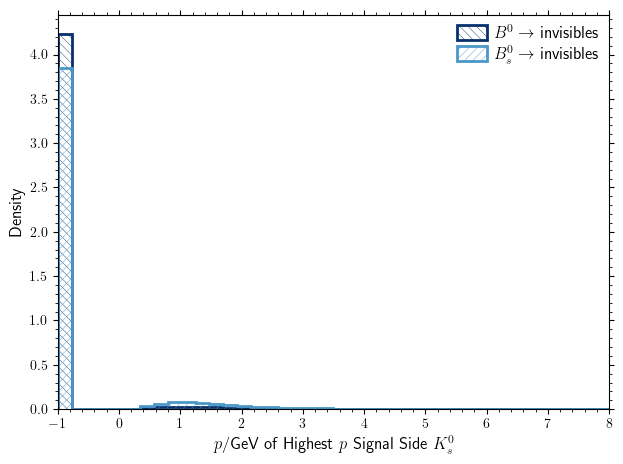

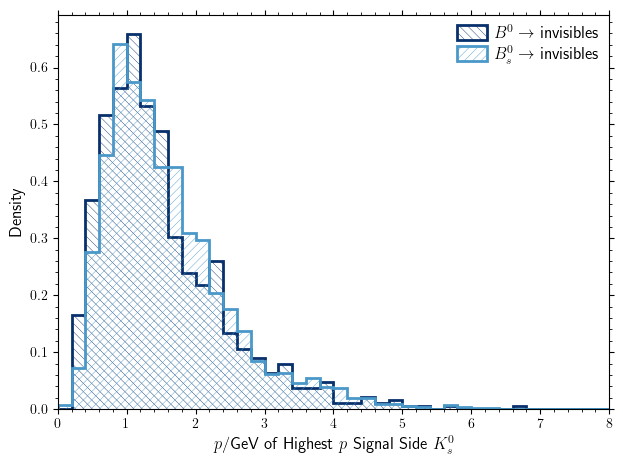

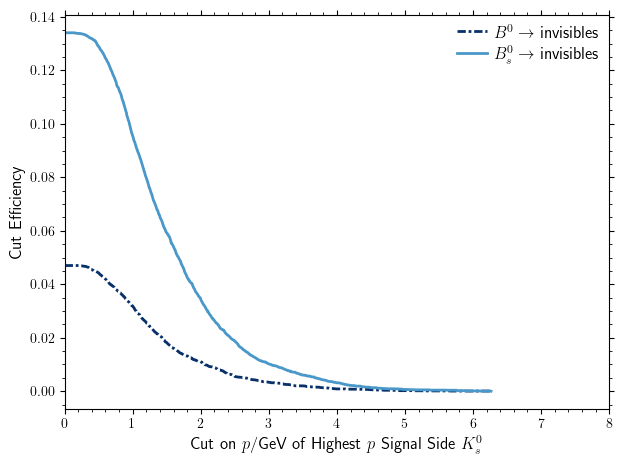

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


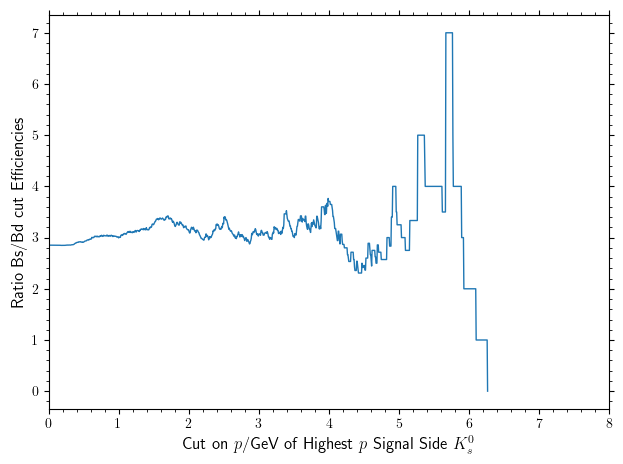

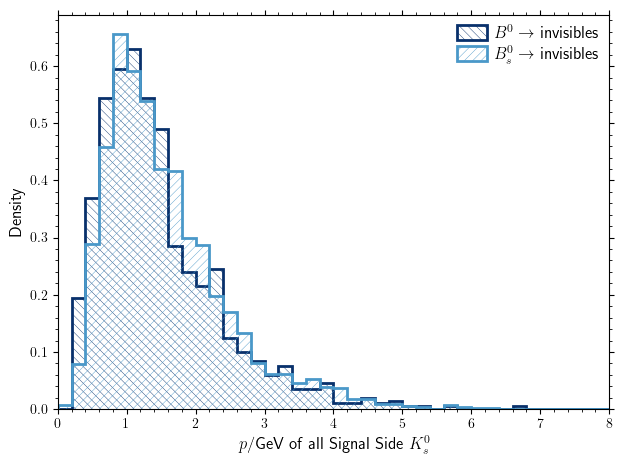

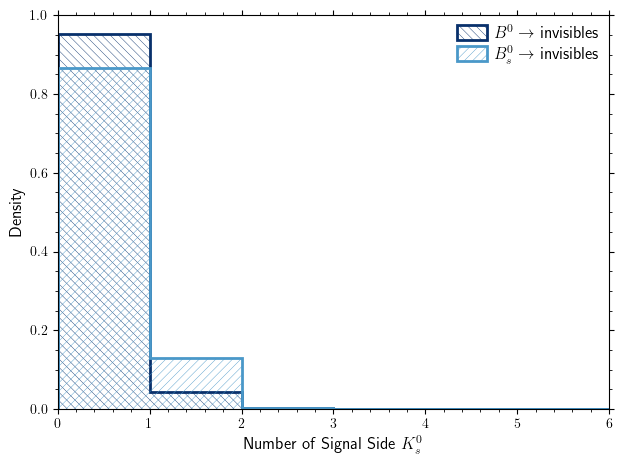

<Figure size 640x480 with 0 Axes>

In [36]:
make_maxpKS_plots(fsKS_dict , savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging',plottype='KS')
make_allpKS_plot(fsKS_dict)
make_nKS_plot(fsKS_dict, savepath='/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/flavour_tagging',plottype='KS')